# 03 - Model Training & Evaluation
---
**Objective:** Train and evaluate machine learning models

**Models:**
- Logistic Regression
- Random Forest
- XGBoost
- LightGBM

**Metrics:**
- Precision, Recall, F1-Score
- ROC-AUC
- Confusion Matrix
- PR Curve

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import shap

# Add project root to path
import os
import sys
sys.path.append(os.path.abspath('../'))
from src.data.loader import load_csv, save_file
from src.models.trainer import (
    split_data, encoding, class_weights, smote_oversampling, 
    clean_feature_names, undersampling
    )
from src.models.evaluator import evaluate_model, evaluate_threshold, plot_PR_curve

# Settings
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

print("Libraries imported successfully!")
print(f"Python version: {sys.version.split()[0]}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully!
Python version: 3.13.5
Pandas version: 2.3.1
NumPy version: 2.3.2


In [2]:
# Load data
train = load_csv('../data/processed/train_features.csv')
print()
test = load_csv('../data/processed/test_features.csv')

👉 Loading: ../data/processed/train_features.csv
DATASET INFORMATION
Shape: 1,296,675 rows × 31 columns
Memory usage: 770.12 MB

Column types:
int64      13
float64    11
object      7
Name: count, dtype: int64

Missing values: 0

👉 Loading: ../data/processed/test_features.csv
DATASET INFORMATION
Shape: 555,719 rows × 31 columns
Memory usage: 330.06 MB

Column types:
float64    12
int64      12
object      7
Name: count, dtype: int64

Missing values: 0


## A. Prepare Data for Modeling

In [3]:
# Split data
X_train, y_train = split_data(train)
X_test, y_test = split_data(test)

# Clean feature names
X_train = clean_feature_names(X_train)
X_test = clean_feature_names(X_test)

# Encode categorical features
X_train, X_test = encoding(X_train, X_test)

# Handle imbalance (class weight)
scale_pos_weight = class_weights(y_train)

Feature shape: (1296675, 30)
scale_pos_weight: 171.75


In [4]:
# SMOTE oversampling
X_smote, y_smote = smote_oversampling(X_train, y_train)

After SMOTE:
is_fraud
0    1289169
1     257833
Name: count, dtype: int64


In [5]:
# Undersampling
X_under, y_under = undersampling(X_train, y_train, strategy=0.1)

After undersampling:
is_fraud
0    75060
1     7506
Name: count, dtype: int64


## B. Train Models

In [6]:
# Logistic Regression (Baseline)
lr_model = LogisticRegression(max_iter=200, class_weight='balanced')
lr_model.fit(X_train, y_train)

evaluate_model(lr_model, X_test, y_test, "Logistic Regression")


-- Logistic Regression --
  Precision : 0.0109
  Recall    : 0.6984
  F2-score  : 0.0514
  ROC-AUC   : 0.79004
  PR-AUC    : 0.07214
Confusion Matrix:
[[417872 135702]
 [   647   1498]]


In [7]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

evaluate_model(rf_model, X_test, y_test, "Random Forest")


-- Random Forest --
  Precision : 0.8784
  Recall    : 0.1347
  F2-score  : 0.1622
  ROC-AUC   : 0.92140
  PR-AUC    : 0.47278
Confusion Matrix:
[[553534     40]
 [  1856    289]]


In [8]:
# XGBoost
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=10,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='aucpr'
)
xgb_model.fit(X_train, y_train)

evaluate_model(xgb_model, X_test, y_test, "XGBoost")


-- XGBoost --
  Precision : 0.7074
  Recall    : 0.2942
  F2-score  : 0.3331
  ROC-AUC   : 0.95275
  PR-AUC    : 0.39625
Confusion Matrix:
[[553313    261]
 [  1514    631]]


In [9]:
# LightGBM
lgb_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

lgb_model.fit(X_train, y_train)

evaluate_model(lgb_model, X_test, y_test, "LightGBM")

[LightGBM] [Info] Number of positive: 7506, number of negative: 1289169
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.039865 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5089
[LightGBM] [Info] Number of data points in the train set: 1296675, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.005789 -> initscore=-5.146050
[LightGBM] [Info] Start training from score -5.146050

-- LightGBM --
  Precision : 0.2357
  Recall    : 0.1865
  F2-score  : 0.1946
  ROC-AUC   : 0.87169
  PR-AUC    : 0.17236
Confusion Matrix:
[[552277   1297]
 [  1745    400]]


## C. Evaluation

### Feature importance

In [10]:
# Feature importance
importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

                Feature  Importance
21           amt_zscore    0.216482
2                   amt    0.215571
20              amt_log    0.172137
19             is_night    0.096079
15                 hour    0.056768
28  category_fraud_rate    0.039361
29      city_fraud_rate    0.031960
25        category_freq    0.031678
1              category    0.027620
27  merchant_fraud_rate    0.025048
24        merchant_freq    0.023300
26            city_freq    0.010352
22                  age    0.008839
10             city_pop    0.005000
12            unix_time    0.004137
0              merchant    0.003323
23          distance_km    0.002948
4                street    0.002894
14           merch_long    0.002890
11                  job    0.002877
5                  city    0.002789
13            merch_lat    0.002752
7                   zip    0.002571
8                   lat    0.002542
9                  long    0.002407
17                month    0.002189
6                 state    0

In [11]:
# Permutation importance
result = permutation_importance(
    xgb_model,
    X_test,
    y_test,
    scoring='average_precision',  
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': result.importances_mean,
    'Importance Std': result.importances_std
}).sort_values(by='Importance', ascending=False)
            
print(perm_df)

                Feature  Importance  Importance Std
2                   amt    0.391444        0.000087
15                 hour    0.257476        0.001234
22                  age    0.247080        0.004034
1              category    0.217416        0.002977
25        category_freq    0.203224        0.003225
28  category_fraud_rate    0.162523        0.004033
3                gender    0.054408        0.003010
10             city_pop    0.041957        0.002492
24        merchant_freq    0.025151        0.001420
27  merchant_fraud_rate    0.016327        0.000742
17                month    0.001913        0.000468
0              merchant    0.001773        0.000647
23          distance_km    0.000204        0.000500
12            unix_time    0.000000        0.000000
18           is_weekend    0.000000        0.000000
20              amt_log    0.000000        0.000000
21           amt_zscore    0.000000        0.000000
4                street   -0.000451        0.000739
16          

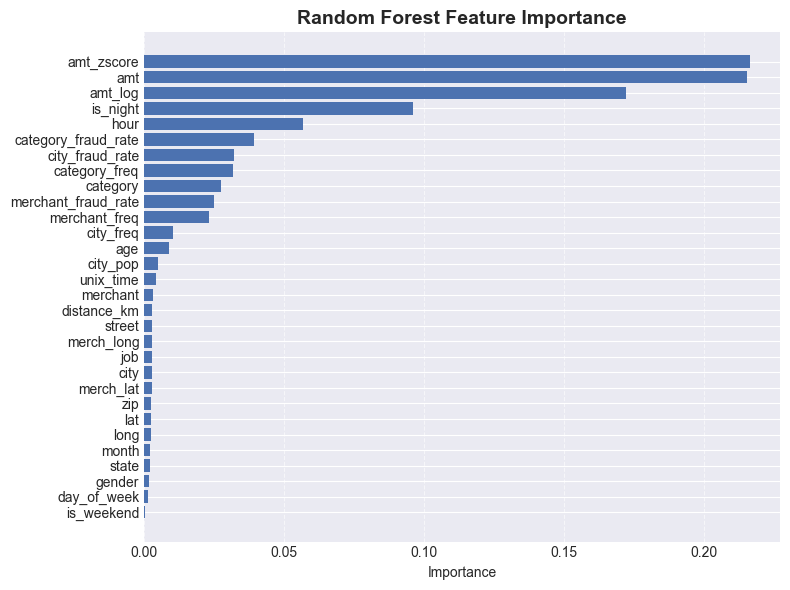

In [12]:
# Plot 1: RF feature importance
fig, ax = plt.subplots(figsize=(8, 6))

ax.barh(
    feature_importance_df['Feature'], 
    feature_importance_df['Importance'],
    color='#4C72B0'   # modern blue
)

ax.invert_yaxis()

ax.set_title("Random Forest Feature Importance", fontsize=14, fontweight='bold')
ax.set_xlabel("Importance")

ax.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

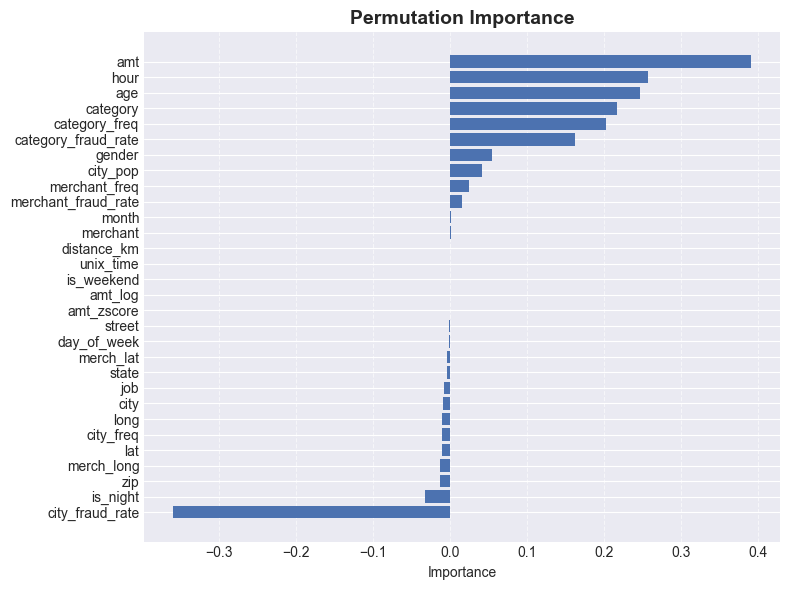

In [13]:
# Plot 2: Permutation importance
fig, ax = plt.subplots(figsize=(8, 6))

ax.barh(
    perm_df['Feature'], 
    perm_df['Importance'],
    color='#4C72B0'   # same modern blue
)

ax.invert_yaxis()

ax.set_title("Permutation Importance", fontsize=14, fontweight='bold')
ax.set_xlabel("Importance")

ax.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("../reports/permutation_importance.png", dpi=300, bbox_inches='tight')
plt.show()

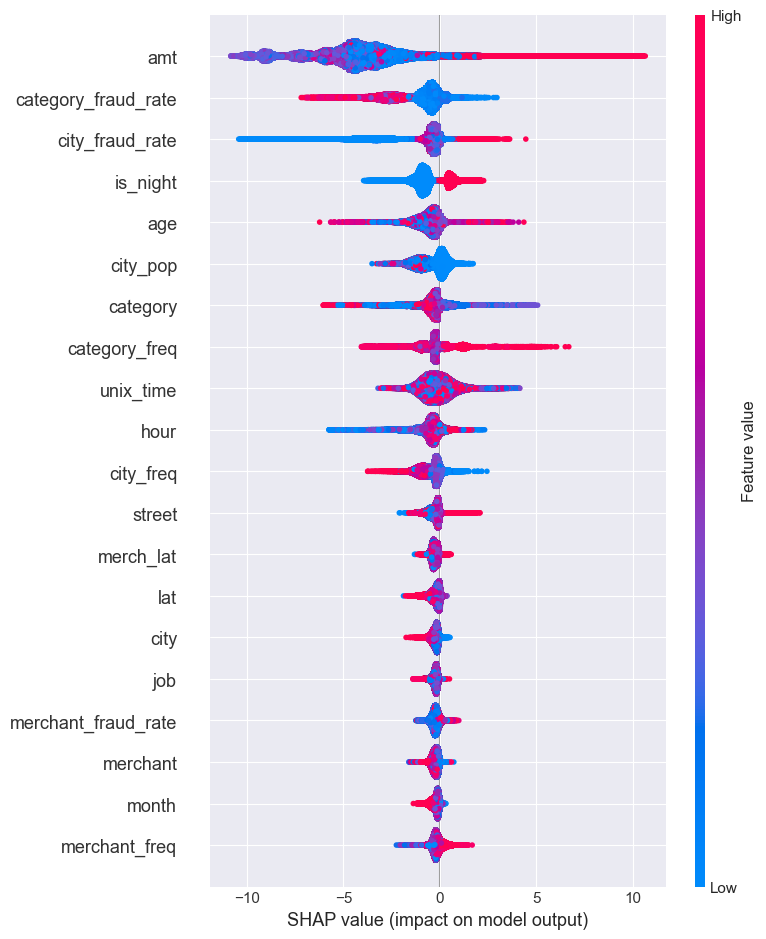

In [21]:
# SHAP
explainer = shap.TreeExplainer(xgb_model)  
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))

shap.summary_plot(shap_values, X_test, show=False)

plt.savefig("../reports/shap_summary.png", dpi=300, bbox_inches='tight')

plt.show()

### Re-train model with top features

In [22]:
FEATURE = ['amt', 'category_fraud_rate', 'category_freq', 'city_pop', 
                'gender', 'hour', 'age', 'merchant_fraud_rate', 'merchant_freq']

In [23]:
# Logistic Regression with selected features
lr_model_new = LogisticRegression(max_iter=200, class_weight='balanced')
lr_model_new.fit(X_train[FEATURE], y_train)

evaluate_model(lr_model_new, X_test[FEATURE], y_test, "Logistic Regression")


-- Logistic Regression --
  Precision : 0.0482
  Recall    : 0.7427
  F2-score  : 0.1915
  ROC-AUC   : 0.83515
  PR-AUC    : 0.12978
Confusion Matrix:
[[522151  31423]
 [   552   1593]]


In [24]:
# Random Forest with selected features
rf_model_new = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model_new.fit(X_train[FEATURE], y_train)

evaluate_model(rf_model_new, X_test[FEATURE], y_test, "Random Forest")


-- Random Forest --
  Precision : 0.9409
  Recall    : 0.7795
  F2-score  : 0.8072
  ROC-AUC   : 0.98376
  PR-AUC    : 0.89482
Confusion Matrix:
[[553469    105]
 [   473   1672]]


In [25]:
# LightGBM with selected features
lgb_model_new = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

lgb_model_new.fit(X_train[FEATURE], y_train)

evaluate_model(lgb_model_new, X_test[FEATURE], y_test, "LightGBM")

[LightGBM] [Info] Number of positive: 7506, number of negative: 1289169
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009614 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1205
[LightGBM] [Info] Number of data points in the train set: 1296675, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.005789 -> initscore=-5.146050
[LightGBM] [Info] Start training from score -5.146050

-- LightGBM --
  Precision : 0.3165
  Recall    : 0.9473
  F2-score  : 0.6773
  ROC-AUC   : 0.99620
  PR-AUC    : 0.88540
Confusion Matrix:
[[549185   4389]
 [   113   2032]]


In [26]:
# XGBoost with selected features
xgb_model_new = XGBClassifier(
    n_estimators=500,
    max_depth=10,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='aucpr'
)

xgb_model_new.fit(X_train[FEATURE], y_train)

evaluate_model(xgb_model_new, X_test[FEATURE], y_test, "XGBoost")


-- XGBoost --
  Precision : 0.6563
  Recall    : 0.8625
  F2-score  : 0.8115
  ROC-AUC   : 0.99653
  PR-AUC    : 0.88719
Confusion Matrix:
[[552605    969]
 [   295   1850]]


### Resampling training set

In [33]:
xgb_model_new.fit(X_smote[FEATURE], y_smote)

evaluate_model(xgb_model_new, X_test[FEATURE], y_test, "XGBoost (SMOTE)")


-- XGBoost (SMOTE) --
  Precision : 0.0652
  Recall    : 0.9604
  F2-score  : 0.2564
  ROC-AUC   : 0.99183
  PR-AUC    : 0.83778
Confusion Matrix:
[[524038  29536]
 [    85   2060]]


In [34]:
xgb_model_new.fit(X_under[FEATURE], y_under)

evaluate_model(xgb_model_new, X_test[FEATURE], y_test, "XGBoost (Undersampling)")


-- XGBoost (Undersampling) --
  Precision : 0.2768
  Recall    : 0.9534
  F2-score  : 0.6403
  ROC-AUC   : 0.99711
  PR-AUC    : 0.88558
Confusion Matrix:
[[548230   5344]
 [   100   2045]]


### Evaluate thresholds

In [31]:
# Evaluate thresholds
evaluate_threshold(xgb_model_new, X_test[FEATURE], y_test, 0.5, "XGBoost")
evaluate_threshold(xgb_model_new, X_test[FEATURE], y_test, 0.3, "XGBoost")
evaluate_threshold(xgb_model_new, X_test[FEATURE], y_test, 0.2, "XGBoost")


-- XGBoost (Threshold = 0.5) --
  Precision : 0.2768
  Recall    : 0.9534
  F2-score  : 0.6403
  ROC-AUC   : 0.99711
  PR-AUC    : 0.88558
Confusion Matrix:
[[548230   5344]
 [   100   2045]]

-- XGBoost (Threshold = 0.3) --
  Precision : 0.2311
  Recall    : 0.9641
  F2-score  : 0.5899
  ROC-AUC   : 0.99711
  PR-AUC    : 0.88558
Confusion Matrix:
[[546693   6881]
 [    77   2068]]

-- XGBoost (Threshold = 0.2) --
  Precision : 0.2052
  Recall    : 0.9664
  F2-score  : 0.5549
  ROC-AUC   : 0.99711
  PR-AUC    : 0.88558
Confusion Matrix:
[[545547   8027]
 [    72   2073]]


### PR Curve

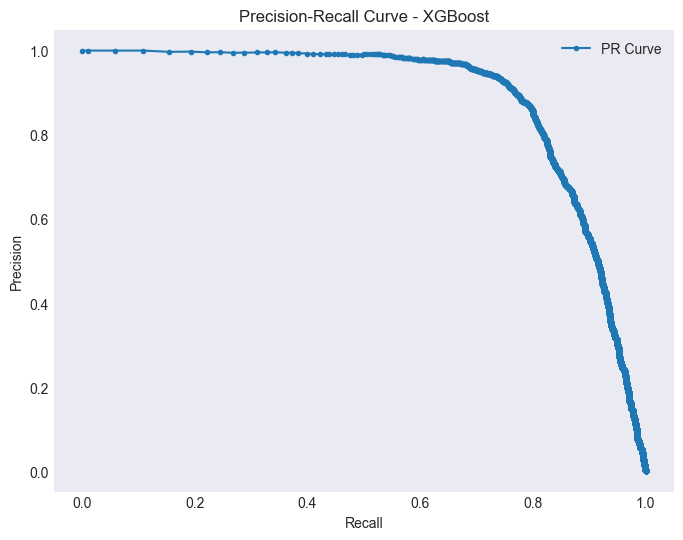

In [32]:
# Plot PR Curve
plot_PR_curve(xgb_model_new, X_test[FEATURE], y_test, name="XGBoost")

## Save data

In [20]:
# Save top features datasets
FEATURES = [
    'amt', 'category_fraud_rate', 'category_freq', 'city_pop',
    'gender', 'hour', 'age', 'merchant_fraud_rate', 'merchant_freq',
    'is_fraud' #target variable
]

save_file(train[FEATURES], 'external/train_top_features.csv')
save_file(test[FEATURES], 'external/test_top_features.csv')

print("✅ Processed data saved successfully!")

File saved as: ../data\external/train_top_features.csv
File saved as: ../data\external/test_top_features.csv
✅ Processed data saved successfully!
